# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [17]:
ROLL_NO = 1024170083         # <-- your full roll number
NAME = "Harshita Joshi"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [18]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [19]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [20]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170083   Name: Harshita Joshi   Fingerprint: 65A664FF   Tickets: 15

Ticket_ID                                                                              Ticket_Text
      T01                                                           Error code 0x80070005 appears.
      T02                                         The password is not working. Can you check this?
      T03       Wifi keeps asking for login after the latest update. It works on another computer.
      T04                                           Re-installing didn't help; log-in still fails!
      T05             I was locked out of the projector when I use mobile hotspot. This is urgent.
      T06               I cannot access the Matlab after resetting my password. Please resolve it.
      T07 I cannot access the projector before the assignment deadline. I don't know what changed.
      T08                                               The lms failed to open. Please resolve it.
      T09              

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [21]:
results = []

for _, row in df.iterrows():
    ticket_id = row["Ticket_ID"]
    ticket_text = row["Ticket_Text"]

    result = process_ticket(ticket_text)

    results.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation Tokens": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique Tokens": len(set(result["tokens"])),
        "Final Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(results)

q1_table

,Ticket_ID,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,1,5,1,0,5,4
1,T02,2,11,2,6,11,3
2,T03,2,16,2,5,15,9
3,T04,1,9,2,1,9,6
4,T05,2,17,2,9,15,6
5,T06,2,15,2,7,14,6
6,T07,2,18,2,9,15,7
7,T08,2,10,2,3,9,5
8,T09,1,11,1,4,9,6
9,T10,2,17,2,8,16,7


In [30]:
# Select the first ticket
ticket_text = df.iloc[0]["Ticket_Text"]

result = process_ticket(ticket_text)

print("Ticket ID:", df.iloc[0]["Ticket_ID"])
print("\nTicket Text:")
print(ticket_text)

print("\nActual Tokens:")
print(result["tokens"])

print("\nPunctuation Tokens:")
print(result["punct"])

print("\nStopwords:")
print(result["stops"])

print("\nFinal Tokens:")
print(result["final"])

Ticket ID: T01

Ticket Text:
Error code 0x80070005 appears.

Actual Tokens:
['error', 'code', '0x80070005', 'appears', '.']

Punctuation Tokens:
['.']

Stopwords:
[]

Final Tokens:
['error', 'code', '0x80070005', 'appears']


[link text](https:// [link text](https:// [link text](https://)))**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer: They come from contractions and possessive forms being split during tokenization.*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [31]:
import re

# Regex patterns

# 1. Words longer than 5 letters
long_words_pattern = r"\b[A-Za-z]{6,}\b"

# 2. Numbers, decimals and version numbers
# Examples: 95, 95.5, 2.0.1
numbers_pattern = r"\b\d+(?:\.\d+)+\b|\b\d+\b"

# 3. Capitalized words
capitalized_pattern = r"\b[A-Z][a-zA-Z]*\b"

# 4. Words beginning with a vowel
vowel_words_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"

# 5. Email addresses
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"

# 6. URLs
url_pattern = r"https?://[^\s<>()]+|www\.[^\s<>()]+"

# 7. Phone numbers
phone_pattern = r"(?<!\d)\+?\d[\d\s().-]{7,}\d(?!\d)"

In [32]:
regex_results = []

for _, row in df.iterrows():

    ticket_id = row["Ticket_ID"]
    ticket_text = row["Ticket_Text"]

    regex_results.append({
        "Ticket_ID": ticket_id,
        "Words > 5 letters": re.findall(long_words_pattern, ticket_text),
        "Numbers": re.findall(numbers_pattern, ticket_text),
        "Capitalized Words": re.findall(capitalized_pattern, ticket_text),
        "Vowel-starting Words": re.findall(vowel_words_pattern, ticket_text)
    })

q2_findall = pd.DataFrame(regex_results)

q2_findall

,Ticket_ID,Words > 5 letters,Numbers,Capitalized Words,Vowel-starting Words
0,T01,[appears],[],[Error],"[Error, appears]"
1,T02,"[password, working]",[],"[The, Can]",[is]
2,T03,"[asking, latest, update, another, computer]",[],"[Wifi, It]","[asking, after, update, It, on, another]"
3,T04,[installing],[],[Re],"[installing, in]"
4,T05,"[locked, projector, mobile, hotspot, urgent]",[],"[I, I, This]","[I, out, of, I, use, is, urgent]"
5,T06,"[cannot, access, Matlab, resetting, password, ...",[],"[I, Matlab, Please]","[I, access, after, it]"
6,T07,"[cannot, access, projector, before, assignment...",[],"[I, I]","[I, access, assignment, I]"
7,T08,"[failed, Please, resolve]",[],"[The, Please]","[open, it]"
8,T09,"[change, anything]",[],"[I, I]","[I, and, I, anything]"
9,T10,"[couldn, connect, restarting, system]",[],"[I, VPN, Can]","[I, after]"


**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer: 15, The capitalized words that occur at the beginning of sentences are capitalized because of sentence-start capitalization rather than because the words themselves require capitalization.*

In [33]:
for i, line in enumerate(TEST_LINES, 1):

    print("=" * 70)
    print("TEST LINE", i)
    print("=" * 70)

    print("Original:")
    print(line)

    print("\nWords > 5 letters:")
    print(re.findall(long_words_pattern, line))

    print("\nNumbers:")
    print(re.findall(numbers_pattern, line))

    print("\nCapitalized Words:")
    print(re.findall(capitalized_pattern, line))

    print("\nVowel-starting Words:")
    print(re.findall(vowel_words_pattern, line))

    text = re.sub(email_pattern, "<EMAIL>", line)
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)

    print("\nAfter Replacement:")
    print(text)

TEST LINE 1
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

Words > 5 letters:
['helpdesk', 'thapar', 'thapar', 'thapar']

Numbers:
[]

Capitalized Words:
['Mail']

Vowel-starting Words:
['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']

After Replacement:
Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>
TEST LINE 2
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

Words > 5 letters:
['Version']

Numbers:
['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1', '250']

Capitalized Words:
['Call', 'Version', 'Rs']

Vowel-starting Words:
['or', 'is']

After Replacement:
Call <PHONE>, <PHONE> or <PHONE>. Version 2.0.1 is 95.5% done; fee Rs 1,250.
TEST LINE 3
Original:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.

Words > 5 letters:
[]

Numbers:
['5.30']

Capitalized Words:
['The'

In [34]:
for i, line in enumerate(TEST_LINES, 1):

    print("=" * 70)
    print("TEST LINE", i)
    print("=" * 70)

    print("Original:")
    print(line)

    print("\nWords > 5 letters:")
    print(re.findall(long_words_pattern, line))

    print("\nNumbers:")
    print(re.findall(numbers_pattern, line))

    print("\nCapitalized Words:")
    print(re.findall(capitalized_pattern, line))

    print("\nVowel-starting Words:")
    print(re.findall(vowel_words_pattern, line))

    text = re.sub(email_pattern, "<EMAIL>", line)
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)

    print("\nAfter Replacement:")
    print(text)

TEST LINE 1
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

Words > 5 letters:
['helpdesk', 'thapar', 'thapar', 'thapar']

Numbers:
[]

Capitalized Words:
['Mail']

Vowel-starting Words:
['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']

After Replacement:
Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>
TEST LINE 2
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

Words > 5 letters:
['Version']

Numbers:
['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1', '250']

Capitalized Words:
['Call', 'Version', 'Rs']

Vowel-starting Words:
['or', 'is']

After Replacement:
Call <PHONE>, <PHONE> or <PHONE>. Version 2.0.1 is 95.5% done; fee Rs 1,250.
TEST LINE 3
Original:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.

Words > 5 letters:
[]

Numbers:
['5.30']

Capitalized Words:
['The'

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [36]:
from nltk.tokenize import RegexpTokenizer

pattern = r"""
https?://[^\s<>()]+
|www\.[^\s<>()]+
|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}
|\+?\d[\d\s().-]{7,}\d
|\d+(?:\.\d+)+
|\d+(?:\.\d+)?
|[A-Za-z]+(?:'[A-Za-z]+)?(?:-[A-Za-z]+(?:'[A-Za-z]+)?)*
|[^\w\s]
"""

tokenizer = RegexpTokenizer(pattern, flags=re.VERBOSE)

def my_tokenize(text):
    return tokenizer.tokenize(text)

In [37]:
for i, line in enumerate(TEST_LINES, 1):
    print(f"\n===== TEST LINE {i} =====")
    print("Original:")
    print(line)

    print("\nMy tokens:")
    print(my_tokenize(line))


===== TEST LINE 1 =====
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

My tokens:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

===== TEST LINE 2 =====
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

My tokens:
['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1', ',', '250', '.']

===== TEST LINE 3 =====
Original:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.

My tokens:
['The', 'state-of-the-art', 'lab', "isn't", 'open', ';', 'log-in', 'at', '5.30', 'p', '.', 'm', '.', "didn't", 'work', '.']


In [38]:
q3_results = []

for _, row in df.iterrows():
    q3_results.append({
        "Ticket_ID": row["Ticket_ID"],
        "Custom Tokens": my_tokenize(row["Ticket_Text"])
    })

q3_table = pd.DataFrame(q3_results)

q3_table

,Ticket_ID,Custom Tokens
0,T01,"[Error, code, 0, x, 80070005, appears, .]"
1,T02,"[The, password, is, not, working, ., Can, you,..."
2,T03,"[Wifi, keeps, asking, for, login, after, the, ..."
3,T04,"[Re-installing, didn't, help, ;, log-in, still..."
4,T05,"[I, was, locked, out, of, the, projector, when..."
5,T06,"[I, cannot, access, the, Matlab, after, resett..."
6,T07,"[I, cannot, access, the, projector, before, th..."
7,T08,"[The, lms, failed, to, open, ., Please, resolv..."
8,T09,"[I, can't, login, and, I, didn't, change, anyt..."
9,T10,"[I, couldn't, connect, to, the, VPN, after, re..."


In [39]:
from nltk.tokenize import word_tokenize

for i, line in enumerate(TEST_LINES, 1):

    custom = my_tokenize(line)
    nltk_tokens = word_tokenize(line)

    print(f"\n===== TEST LINE {i} =====")
    print("Original:")
    print(line)

    print("\nmy_tokenize():")
    print(custom)

    print("\nword_tokenize():")
    print(nltk_tokens)


===== TEST LINE 1 =====
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

my_tokenize():
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

word_tokenize():
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

===== TEST LINE 2 =====
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

my_tokenize():
['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1', ',', '250', '.']

word_tokenize():
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

===== TEST LIN

In [40]:
for i, line in enumerate(TEST_LINES, 1):

    custom = my_tokenize(line)
    nltk_tokens = word_tokenize(line)

    if custom != nltk_tokens:
        print(f"\n===== DIFFERENCE {i} =====")
        print("Original:", line)
        print("my_tokenize():", custom)
        print("word_tokenize():", nltk_tokens)


===== DIFFERENCE 1 =====
Original: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
my_tokenize(): ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']
word_tokenize(): ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

===== DIFFERENCE 2 =====
Original: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
my_tokenize(): ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1', ',', '250', '.']
word_tokenize(): ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

===== DIFFERENCE

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:3 tickets are tokenized differently by my_tokenize() and word_tokenize().*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [41]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

porter = PorterStemmer()
lancaster = LancasterStemmer()

# Regexp stemmer
regexp_stemmer = RegexpStemmer(r"(ing|ed|es|s)$", min=3)

lemmatizer = WordNetLemmatizer()

final_tokens = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    final_tokens.extend(result["final"])

unique_final_tokens = sorted(set(final_tokens))

print("Number of unique final tokens:", len(unique_final_tokens))

Number of unique final tokens: 61


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:Over-stemming: "error" → "er" using Lancaster Stemmer.

Under-stemming: "projector" → "projector" using Lancaster Stemmer, while Porter gives "project".*

In [43]:
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [44]:
tagged_words = pos_tag(unique_final_tokens)

stem_results = []

for word, tag in tagged_words:

    wn_pos = get_wordnet_pos(tag)

    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp_stemmer.stem(word)
    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    # Only keep words where outputs differ
    if len({
        porter_result,
        lancaster_result,
        regexp_result,
        lemma_result
    }) > 1:

        stem_results.append({
            "Word": word,
            "POS": tag,
            "Porter": porter_result,
            "Lancaster": lancaster_result,
            "Regexp": regexp_result,
            "WordNet Lemmatizer": lemma_result
        })

q4_table = pd.DataFrame(stem_results)

q4_table

,Word,POS,Porter,Lancaster,Regexp,WordNet Lemmatizer
0,access,NN,access,access,acces,access
1,another,DT,anoth,anoth,another,another
2,anything,NN,anyth,anyth,anyth,anything
3,assignment,NN,assign,assign,assignment,assignment
4,call,VB,call,cal,call,call
5,change,NN,chang,chang,change,change
6,changed,VBD,chang,chang,chang,change
7,code,NN,code,cod,code,code
8,computer,NN,comput,comput,computer,computer
9,deadline,VB,deadlin,deadlin,deadline,deadline


In [45]:
regexp_examples = []

for word in unique_final_tokens:

    stemmed = regexp_stemmer.stem(word)

    if stemmed != word:
        regexp_examples.append({
            "Original": word,
            "Regexp Stem": stemmed
        })

pd.DataFrame(regexp_examples)

,Original,Regexp Stem
0,access,acces
1,anything,anyth
2,appears,appear
3,asking,ask
4,changed,chang
5,failed,fail
6,fails,fail
7,keeps,keep
8,lms,lm
9,locked,lock


---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

In [46]:
from collections import Counter
import pandas as pd

# S1 = all tokens
S1 = []

# S2 = tokens without punctuation
S2 = []

# S3 = final tokens
S3 = []

for _, row in df.iterrows():

    result = process_ticket(row["Ticket_Text"])

    # S1
    S1.extend(result["tokens"])

    # S2: remove punctuation tokens
    S2.extend([
        token for token in result["tokens"]
        if token not in result["punct"]
    ])

    # S3
    S3.extend(result["final"])

# S4 = S3 after Porter stemming
S4 = [porter.stem(token) for token in S3]


# Function to calculate statistics
def corpus_stats(tokens):
    total_tokens = len(tokens)
    unique_tokens = len(set(tokens))
    ttr = unique_tokens / total_tokens if total_tokens != 0 else 0

    return total_tokens, unique_tokens, ttr


q5_table = pd.DataFrame([
    ["S1", *corpus_stats(S1)],
    ["S2", *corpus_stats(S2)],
    ["S3", *corpus_stats(S3)],
    ["S4", *corpus_stats(S4)]
], columns=[
    "Corpus",
    "Total Tokens",
    "Unique Tokens",
    "TTR"
])

q5_table

,Corpus,Total Tokens,Unique Tokens,TTR
0,S1,190,91,0.478947
1,S2,163,87,0.533742
2,S3,88,61,0.693182
3,S4,88,58,0.659091


In [47]:
print("TOP 10 WORDS OF S1")
print("=" * 40)

for word, count in Counter(S1).most_common(10):
    print(word, ":", count)


print("\nTOP 10 WORDS OF S3")
print("=" * 40)

for word, count in Counter(S3).most_common(10):
    print(word, ":", count)

TOP 10 WORDS OF S1
. : 21
the : 13
i : 9
is : 6
after : 6
can : 5
this : 5
n't : 5
not : 4
password : 3

TOP 10 WORDS OF S3
n't : 5
password : 3
working : 3
check : 3
please : 3
restarting : 3
system : 3
error : 2
login : 2
latest : 2


**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*

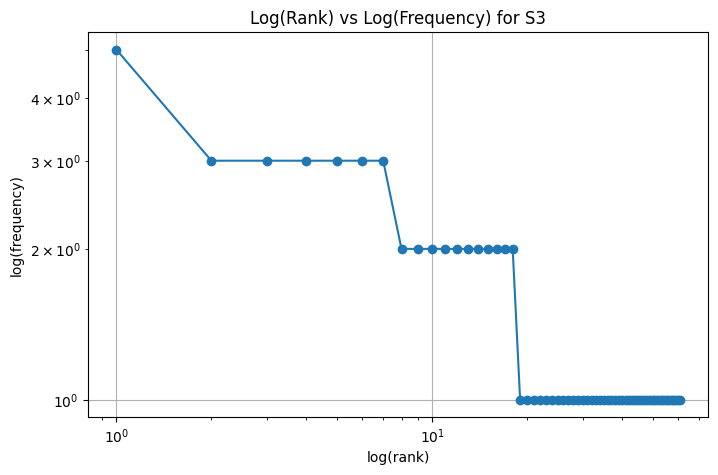

In [48]:
import matplotlib.pyplot as plt

frequency = sorted(
    Counter(S3).values(),
    reverse=True
)

rank = list(range(1, len(frequency) + 1))

plt.figure(figsize=(8, 5))

plt.loglog(
    rank,
    frequency,
    marker="o"
)

plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Log(Rank) vs Log(Frequency) for S3")

plt.grid(True)
plt.show()

In [49]:
def get_bigrams(tokens):
    return list(zip(tokens[:-1], tokens[1:]))


S1_bigrams = get_bigrams(S1)
S3_bigrams = get_bigrams(S3)


print("TOP 5 BIGRAMS OF S1")
print("=" * 40)

for bigram, count in Counter(S1_bigrams).most_common(5):
    print(bigram, ":", count)


print("\nTOP 5 BIGRAMS OF S3")
print("=" * 40)

for bigram, count in Counter(S3_bigrams).most_common(5):
    print(bigram, ":", count)

TOP 5 BIGRAMS OF S1
('.', 'i') : 6
('.', 'can') : 3
('can', 'you') : 3
('you', 'check') : 3
('check', 'this') : 3

TOP 5 BIGRAMS OF S3
('restarting', 'system') : 3
('password', 'working') : 2
('latest', 'update') : 2
('please', 'resolve') : 2
('system', 'check') : 2
